<a href="https://colab.research.google.com/github/RoshnaGeorge/ML/blob/main/Lab%202/Lab02_A7_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A7: Heatmap Plot for Similarity Measures

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load ->thyroid dataset
thyroid_data = pd.read_excel(
    "Lab Session Data.xlsx",
    sheet_name="thyroid0387_UCI"
)

first_20 = thyroid_data.iloc[:20].copy()
print("Shape of first 20 observations:", first_20.shape)

Shape of first 20 observations: (20, 31)


prep of binary attributes for JC,SMC

In [9]:
#binary attributes
bin_col = []
for col in thyroid_data.columns:
    uniq_val = set(thyroid_data[col].dropna().unique())

    if uniq_val.issubset({'t', 'f'}) and len(uniq_val) > 0:
        bin_col.append(col)

bin_data = first_20[bin_col].replace({'t': 1, 'f': 0})

bin_vectors = bin_data.to_numpy()

print("Number of Binary Attributes:", len(bin_col))
print("Shape of Binary Data:", bin_vectors.shape)

Number of Binary Attributes: 20
Shape of Binary Data: (20, 20)


/tmp/ipykernel_649/558142941.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bin_data = first_20[bin_col].replace({'t': 1, 'f': 0})


calc of pairwise JC,SMC

In [10]:

n = 20
jc_m = np.zeros((n, n))
smc_m = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        vector1 = bin_vectors[i]
        vector2 = bin_vectors[j]

        f11 = np.sum((vector1 == 1) & (vector2 == 1))
        f00 = np.sum((vector1 == 0) & (vector2 == 0))
        f01 = np.sum((vector1 == 0) & (vector2 == 1))
        f10 = np.sum((vector1 == 1) & (vector2 == 0))

        # JC
        denom_jc = f01 + f10 + f11
        if denom_jc != 0:
            jc_m[i, j] = f11 / denom_jc
        else:
            jc_m[i, j] = 1.0

        # SMC
        smc_m[i, j] = (
            (f11 + f00) /
            (f00 + f01 + f10 + f11)
        )
print("JC Matrix:")
print(jc_m)

print("\nSMC Matrix:")
print(smc_m)

JC Matrix:
[[1.         0.25       0.         0.         0.         0.
  0.         0.25       0.25       0.25       0.25       0.25
  0.33333333 0.25       0.         0.5        0.25       0.
  0.14285714 0.28571429]
 [0.25       1.         0.         0.         0.         0.
  0.         1.         1.         1.         1.         1.
  0.25       1.         0.25       0.33333333 1.         0.66666667
  0.28571429 0.42857143]
 [0.         0.         1.         0.5        0.5        0.5
  0.5        0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.125     ]
 [0.         0.         0.5        1.         1.         1.
  1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.5        1.         1.         1.
  1.         0.         0.         0.         0.         0.
  0.         0.         0.         0. 

cosine similarity

In [11]:
cos_data = first_20.replace('?', np.nan)
cos_data = pd.get_dummies(cos_data, dummy_na=True)
cos_data = cos_data.astype(float)
cos_data = cos_data.fillna(0)

comp_vectors = cos_data.to_numpy()

print("shape:", comp_vectors.shape)

shape: (20, 70)


/tmp/ipykernel_649/1817072241.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cos_data = first_20.replace('?', np.nan)


pairwise cos similarity

In [12]:

cos_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        vector_A = comp_vectors[i]
        vector_B = comp_vectors[j]

        dot_prod = np.dot(vector_A, vector_B)

        mag_A = np.linalg.norm(vector_A)
        mag_B = np.linalg.norm(vector_B)

        if mag_A != 0 and mag_B != 0:
            cos_matrix[i, j] = (
                dot_prod / (mag_A * mag_B)
            )

print("cosine similarity matrix:")
print(cos_matrix)

cosine similarity matrix:
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 

heatmaps

JC heatmap

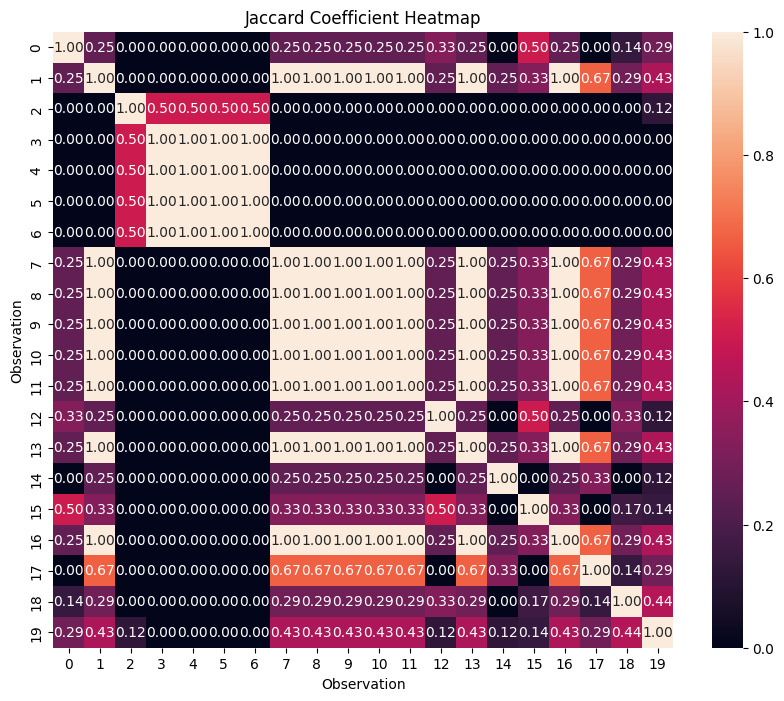

In [13]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(jc_m, annot=True, fmt=".2f")
plt.title("Jaccard Coefficient Heatmap")
plt.xlabel("Observation")
plt.ylabel("Observation")

plt.show()

SMC Heatmap

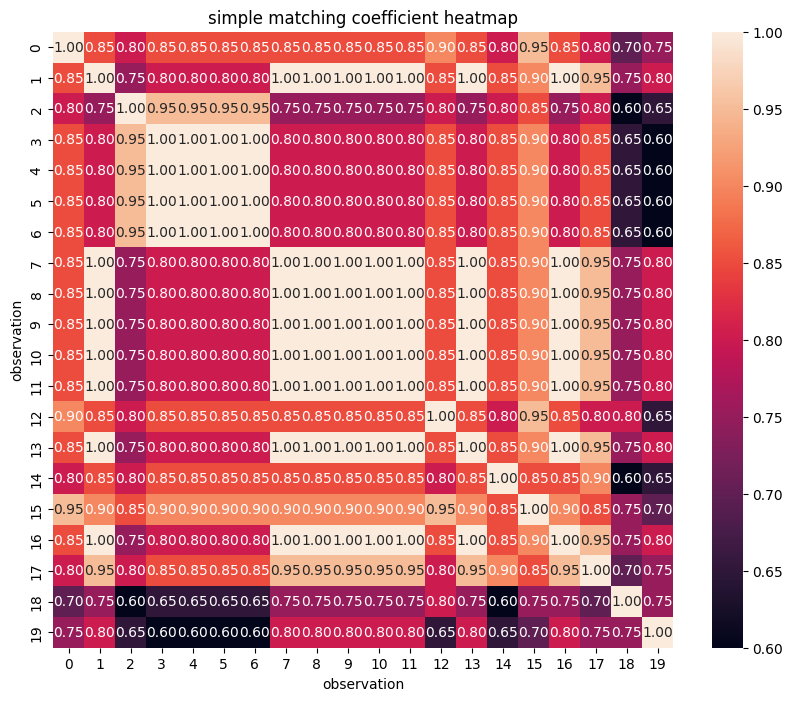

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(smc_m, annot=True, fmt=".2f")
plt.title("simple matching coefficient heatmap")
plt.xlabel("observation")
plt.ylabel("observation")
plt.show()

cosine similarity heatmap

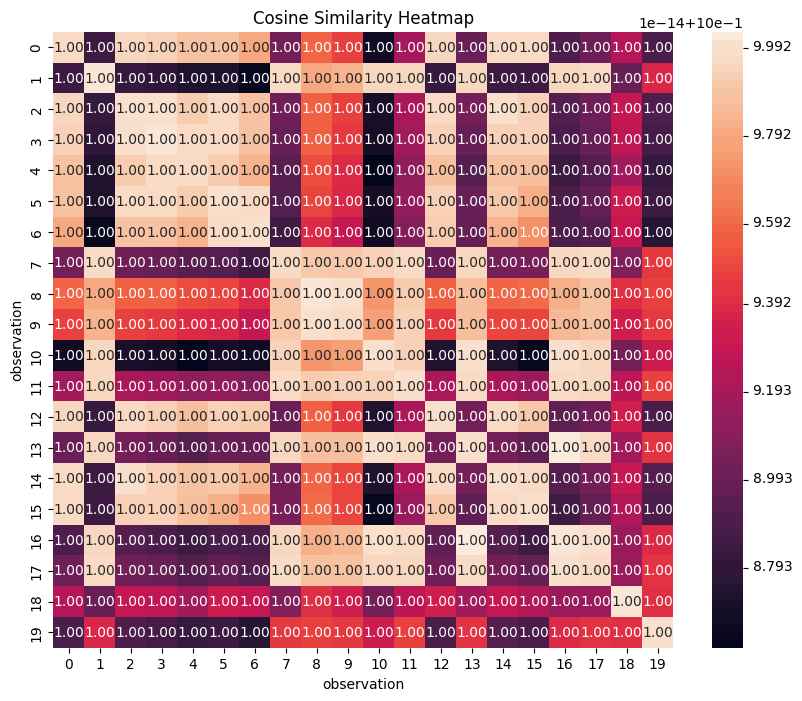

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(cos_matrix, annot=True, fmt=".2f")
plt.title("Cosine Similarity Heatmap")
plt.xlabel("observation")
plt.ylabel("observation")
plt.show()